In [1]:
library(ggplot2)
library(lme4)
library(lmerTest)
library(dplyr)

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df <- read.csv('data/RGC_count/RGC_count.csv')

In [3]:
df$count <- df$count/(0.425*0.425) # 0.425mm*0.425mm

In [4]:
df$area <- factor(as.character(df$area))
df$sample <- factor(df$sample)

In [5]:
result <- df %>%
  group_by(area) %>%
  group_modify(~{
    
    fit <- lmer(
      count ~ time + (1 | sample),
      data = .x
    )
    
    coef <- summary(fit)$coefficients
    
    data.frame(
      estimate = coef["time", "Estimate"],
      p.value = coef["time", "Pr(>|t|)"]
    )
  })

boundary (singular) fit: see help('isSingular')



In [6]:
result

area,estimate,p.value
<fct>,<dbl>,<dbl>
central,-185.13921,3.330213e-07
mid,-94.05635,2.992155e-04
peripheral,-41.47945,1.501546e-02


In [7]:
sample_mean <- df %>%
  group_by(time, area, sample) %>%
  summarise(
    count_mean = mean(count),
    .groups = "drop"
  )

In [8]:
plot_summary <- sample_mean %>%
  group_by(time, area) %>%
  summarise(
    mean = mean(count_mean),
    sd = sd(count_mean),
    n = n(),
    sem = sd / sqrt(n),
    .groups = "drop"
  )

`geom_smooth()` using formula = 'y ~ x'


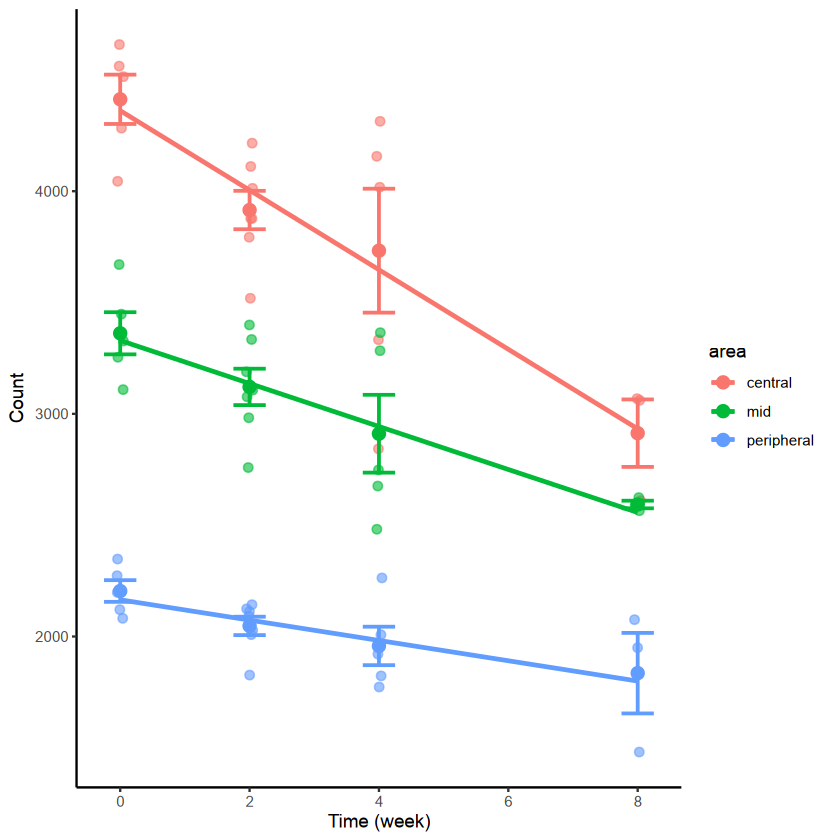

In [9]:
ggplot(sample_mean, aes(x = time, y = count_mean, color = area)) +
  geom_point(size = 2, alpha = 0.6, position = position_jitter(width = 0.05)) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1) +
  geom_point(data = plot_summary, aes(x = time, y = mean), size = 3) +
  geom_errorbar(data = plot_summary, aes(y = mean, ymin = mean - sem, ymax = mean + sem), width = 0.5, linewidth = 0.8) +
  theme_classic() +
  labs(x = "Time (week)", y = "Count")